In [2]:
#!pip install jax
#!pip install lightkurve
import numpy as np
import lightkurve as lk
import matplotlib.pyplot as plt
import pandas as pd
import csv
import glob
import os
from astropy.io import fits
from scipy.ndimage import uniform_filter1d
from scipy.optimize import curve_fit
from tqdm import tqdm

In [3]:
#DEFINE SCALING RELATION
    
def delta_nu_from_numax(numax):
    return 0.263 * numax**0.772
    
#DEFINE SLIDING AUTOCORRELATION
    
def sliding_acf_search(frequency, #frequency array
                       power_flat, #flattened power spectrum
                       numax_grid, #array of values of nu_max to run autocorrelation around
                       k_width=4.0, #width of each window as a multiple of delta_nu
                       lag_frac=(0.8, 1.2) 
                      ):
    
    acf_strength = [] #array to store acf strengths for each nu_max in numax_grid
    df = frequency[1] - frequency[0] #frequency resolution
    for nu_c in numax_grid:
    
        #use scaling relation to get estimated delta_nu for each nu_max
        dnu = delta_nu_from_numax(nu_c)
    
        #window width
        W = k_width * dnu

        #create mask of width W around nu_c
        mask = (frequency > nu_c - W/2) & (frequency < nu_c + W/2)
        if mask.sum() < 20:
            acf_strength.append(0.0)
            continue
    
        # local, whitened spectrum (normalises, so oscillations stand out)
        p = power_flat[mask]
        p = p / np.median(p)
    
        # autocorrelation
        acf = np.correlate(p - np.mean(p), p - np.mean(p), mode="full")
        acf = acf[acf.size//2:] #keep only the positive lag values, because the acf is symmetric
    
        # lag axis
        lag = np.arange(acf.size) * df
    
        # measure strength near Δν
        lag_mask = (lag > lag_frac[0]*dnu) & (lag < lag_frac[1]*dnu)
        strength = np.max(acf[lag_mask])
    
        acf_strength.append(strength)
    
    return np.array(acf_strength)

#DEFINE MASK AROUND DELTA_NU_EST PEAK

def mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac):    
        
        # Central window around delta_nu
        main_lo = delta_nu_est * (1 - window_frac)
        main_hi = delta_nu_est * (1 + window_frac)
    
        mask = (
            (lags > main_lo) & (lags < main_hi)
        )
    
        return lags[mask], acf[mask]

#FUNCTIONS FOR GENERATING NOISE

def random(values):
    randomised = []
    for i in values:
        a=np.random.uniform(0,1)
        randomised.append(i*-np.log(a))
    return randomised

def fake_signals(freqs, N, noise_lvl):
    # freqs: list of frequencies
    # N: number of different fake signals
    # noise_lvl: desired whitenoise level
    #returns N noise only spectra
    signals= []
    for i in tqdm(range(0,N)):
        fake_base=[noise_lvl]*len(freqs)
        fake_signal=random(fake_base)
        signals.append(fake_signal)
    return np.array(signals)

#DEFINE GAUSSIAN

def gaussian(x, A, mu, sigma, c):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + c

#FIND METRICS FOR DETECTION STRENGTH OF NU_MAX, DELTA_NU AND COMBINED METRIC

def find_metric(power, freq):
    #SMOOTHING
        
    df = np.median(np.diff(freq))  # µHz
    smooth_width_muHz = 500    #justify smoothing choice - larger scales than delta_nu
    smooth_width_bins = int(smooth_width_muHz / df)
    background = uniform_filter1d(power, size =smooth_width_bins) #find background
    power_flat = power / background #divide out background to flatten the spectrum
        
    #CALL SLIDING AUTOCORRELATOR, GET NU_MAX_METRIC
        
    numax_grid = np.linspace(50, nu_nyq, 500)   #should run up to nyquist (maximum) frequency
        
    acf_power = sliding_acf_search(
        freq,
        power_flat,
        numax_grid,
        k_width=4.0
    )
    nu_max_peak = np.max(acf_power)
    baseline1 = np.median(acf_power)
    scatter1 = np.std(acf_power)
    nu_max_metric = (nu_max_peak - baseline1) / scatter1 #nu_max_metric is a signal to noise ratio of the acf peak
    
    numax_est = numax_grid[np.argmax(acf_power)]
        
    #RUN AUTOCORRELATION AROUND DELTA_NU_EST
        
    delta_nu_est = delta_nu_from_numax(numax_est)
    width = 4* delta_nu_est
    mask = (freq >= numax_est - width/2) & (freq <= numax_est + width/2)
    freq_window = freq[mask]
    power_window = power_flat[mask]
        
    acf_full = np.correlate(power_window, power_window, mode="full")
    N = len(power_window)
    acf = acf_full[N-1:]
    lags_bins = np.arange(len(acf))
    lags_muHz = lags_bins * df
    acf /= acf[0]
        
    #FIND ACF MAX WITHIN MASK, GIVING DELTA_NU_METRIC
        
    lags_fit, acf_fit = mask_acf_for_deltanu(
        lags_muHz,
        acf,
        delta_nu_est,
        window_frac=0.2
    )
    peak2 = np.max(acf_fit)
    baseline2 = np.median(acf_fit)
    scatter2 = np.std(acf_fit)
    
    delta_nu_metric = (peak2 - baseline2)/scatter2 #SNR of acf peak around delta_nu
    
    return nu_max_metric, delta_nu_metric, lags_fit, acf_fit, delta_nu_est, acf_power

def final_fit(lags_fit, acf_fit, delta_nu_est, acf_power):
    if len(acf_fit) < 5 or np.all(acf_fit == acf_fit[0]):
        delta_nu_metric = np.nan
        delta_nu_fit = delta_nu_est
        delta_nu_err = np.nan
    else:
        peak = np.max(acf_fit)
        baseline2 = np.median(acf_fit)
        scatter2 = np.std(acf_fit)
        delta_nu_metric = (peak - baseline2)/scatter2

        # ---- Gaussian fit to Δν ----
        p0 = [peak, delta_nu_est, 0.2*delta_nu_est, baseline2]
        bounds = ([0, 0.5*delta_nu_est, 0.01*delta_nu_est, -np.inf],
                  [np.inf, 1.5*delta_nu_est, 1.0*delta_nu_est, np.inf])
        try:
            popt, pcov = curve_fit(gaussian, lags_fit, acf_fit, p0=p0, bounds=bounds, maxfev=5000)
            delta_nu_fit = popt[1]
            delta_nu_err = np.sqrt(pcov[1,1])
        except RuntimeError:
            delta_nu_fit = delta_nu_est
            delta_nu_err = np.nan

    df = np.median(np.diff(freq))

    smooth_env_bins = int(1.5 * delta_nu_fit / df)
    envelope = uniform_filter1d(acf_power, size=smooth_env_bins)
    
    numax_grid = np.linspace(50, nu_nyq, 500)
    numax_est = numax_grid[np.argmax(acf_power)]
    
    mask_env = (numax_grid > numax_est - 5*delta_nu_fit) & (numax_grid < numax_est + 5*delta_nu_fit)
    if np.any(mask_env):
        p0 = [acf_power[mask_env].max(), numax_est, 2*delta_nu_fit, 1]
        try:
            popt, pcov = curve_fit(gaussian, numax_grid[mask_env], acf_power[mask_env], p0=p0, maxfev=5000)
            nu_max_fit = popt[1]
            nu_max_err = np.sqrt(pcov[1,1])
        except RuntimeError:
            nu_max_fit = numax_est
            nu_max_err = np.nan
    else:
        nu_max_fit = numax_est
        nu_max_err = np.nan
            
    return delta_nu_fit, delta_nu_err, nu_max_fit, nu_max_err

def find_noise_lvl(power, freq, nu_max_fit, nu_max_err):
    nu_start = nu_max_fit + 3*nu_max_err
    nu_end = freq.max()
    mask = (freq >= nu_start) & (freq <= nu_end)
    noise_lvl = np.median(power[mask]) / np.log(2)
    return noise_lvl

In [4]:
fits_file = r"C:\Users\douga\Documents\Asteroseismology\Simdata\LOPS2PICtarget2.1.0.1-t-fg-c-scv.fits"
csv_file  = r"C:\Users\douga\Documents\Asteroseismology\Simdata\Adjusted final list.csv"

def list_import(path):
    with open(path, "r", newline="", encoding="utf-8-sig") as f:
        return list(csv.reader(f))

def fits_col_to_str_array(col):
    out = []
    for x in col:
        if isinstance(x, (bytes, bytearray)):
            out.append(x.decode("utf-8", errors="ignore").strip())
        else:
            out.append(str(x).strip())
    return np.array(out, dtype=object)

star_list = list_import(csv_file)

# Optional header detection (simple heuristic)
start_idx = 1 if len(star_list) > 0 and not star_list[0][0].startswith("Gaia") else 0

# Build list of requested PIC names from CSV first column
csv_picnames = []
star_labels = []   # stores the f"{mystar[0]}: M = {mystar[1]}, R = {mystar[2]}" strings

for i in range(start_idx, len(star_list)):
    mystar = star_list[i]
    if len(mystar) < 3:
        continue  # skip malformed rows

    picname = str(mystar[0]).strip()
    csv_picnames.append(picname)

    # Build the label you mentioned (if columns 1 and 2 exist)
    try:
        star_name = f"{mystar[0]}: M = {mystar[1]}, R = {mystar[2]} Gmag = {mystar[4]}"
    except IndexError:
        star_name = str(mystar[0])
    star_labels.append(star_name)

with fits.open(fits_file) as hdul:
    data = hdul[1].data  # assumes table is in extension 1

    # Check required columns exist
    required = ["PICname", "Gmag", "BOLrandomSysNSRNCAM_T"]
    missing = [c for c in required if c not in data.columns.names]
    if missing:
        raise KeyError(f"Missing required FITS columns: {missing}")

    # Convert PICname column to clean strings for matching
    fits_picnames = fits_col_to_str_array(data["PICname"])

    # Build a lookup: PICname -> row index
    # (if duplicates exist, this keeps the first occurrence)
    pic_to_index = {}
    for idx, name in enumerate(fits_picnames):
        if name not in pic_to_index:
            pic_to_index[name] = idx

    # Output arrays
    Gmag_array = []
    BOLrandomSysNSRNCAM_T_array = []

    # Optional bookkeeping
    matched_picnames = []
    matched_star_labels = []
    not_found = []

    # Match CSV entries to FITS rows and extract values
    for picname, star_label in zip(csv_picnames, star_labels):
        idx = pic_to_index.get(picname)

        if idx is None:
            not_found.append(picname)
            continue

        gmag_val = data["Gmag"][idx]
        bol_val  = data["BOLrandomSysNSRNCAM_T"][idx]

        # Convert numpy scalars -> Python scalars if needed
        if isinstance(gmag_val, np.generic):
            gmag_val = gmag_val.item()
        if isinstance(bol_val, np.generic):
            bol_val = bol_val.item()

        Gmag_array.append(gmag_val)
        BOLrandomSysNSRNCAM_T_array.append(bol_val)
        matched_picnames.append(picname)
        matched_star_labels.append(star_label)

# Convert to numpy arrays
Gmag_array = np.array(Gmag_array, dtype=float)
BOLrandomSysNSRNCAM_T_array = np.array(BOLrandomSysNSRNCAM_T_array, dtype=float)

# -----------------------------
# Results
# -----------------------------
print(f"Matched {len(Gmag_array)} stars")
print(f"Not found in FITS: {len(not_found)}")

if not_found:
    print("\nFirst few not found:")
    for x in not_found[:10]:
        print("  ", x)

# These are your two separate arrays:
print("\nPIC_IDs:")
print(matched_picnames)

print("\nBOLrandomSysNSRNCAM_T_array:")
print(BOLrandomSysNSRNCAM_T_array)

DF1 = pd.DataFrame({"PIC_ID": matched_picnames,
                    "sig1hr": BOLrandomSysNSRNCAM_T_array,
                    "Gmag": Gmag_array
                   })
print(DF1)

Matched 33 stars
Not found in FITS: 0

PIC_IDs:
['PIC 2915577000081', 'PIC 2915571000104', 'PIC 2912861000050', 'PIC 2908735000056', 'PIC 2908735000057', 'PIC 2901793000033', 'PIC 2897612000102', 'PIC 2893330000017', 'PIC 2890529000062', 'PIC 2889072000139', 'PIC 2886168000063', 'PIC 2886166000078', 'PIC 2886218000135', 'PIC 2886191000129', 'PIC 2883305000009', 'PIC 2880424000123', 'PIC 2880424000128', 'PIC 2878914000067', 'PIC 2878966000167', 'PIC 2877464000062', 'PIC 2874507000079', 'PIC 2870094000052', 'PIC 2868606000109', 'PIC 2868638000148', 'PIC 2864154000102', 'PIC 2862637000040', 'PIC 2861112000105', 'PIC 2856556000125', 'PIC 2847353000081', 'PIC 2844331000233', 'PIC 2841143000066', 'PIC 2833293000069', 'PIC 2705309000027']

BOLrandomSysNSRNCAM_T_array:
[19.51000023 18.09000015 25.93000031 20.35000038 24.15999985 16.28000069
 19.23999977 26.70999908 11.36999989 21.88999939 21.13999939 19.46999931
 23.17000008 25.35000038 25.18000031 17.17000008 19.87000084 15.85000038
 23.34000

In [5]:
def shot_noise(star_name, power):
    power = np.asarray(power).squeeze()  # make sure it's 1D

    mask = (DF1["PIC_ID"].astype(str) == str(star_name))
    sig_series = DF1.loc[mask, "sig1hr"]

    if sig_series.empty:
        raise KeyError(f"No match for PIC_ID={star_name}")
    if len(sig_series) > 1:
        raise ValueError(f"Multiple matches for PIC_ID={star_name}")

    sig1hr = float(sig_series.iloc[0])  # scalar

    bg_noise = 2 * (sig1hr**2) * 3600 * 1e-6
    spectrum = power + bg_noise

    noisy_spec = []
    for x in spectrum:
        a = np.random.uniform(0, 1)
        noisy_spec.append(x * (-np.log(a)))

    return np.array(noisy_spec)

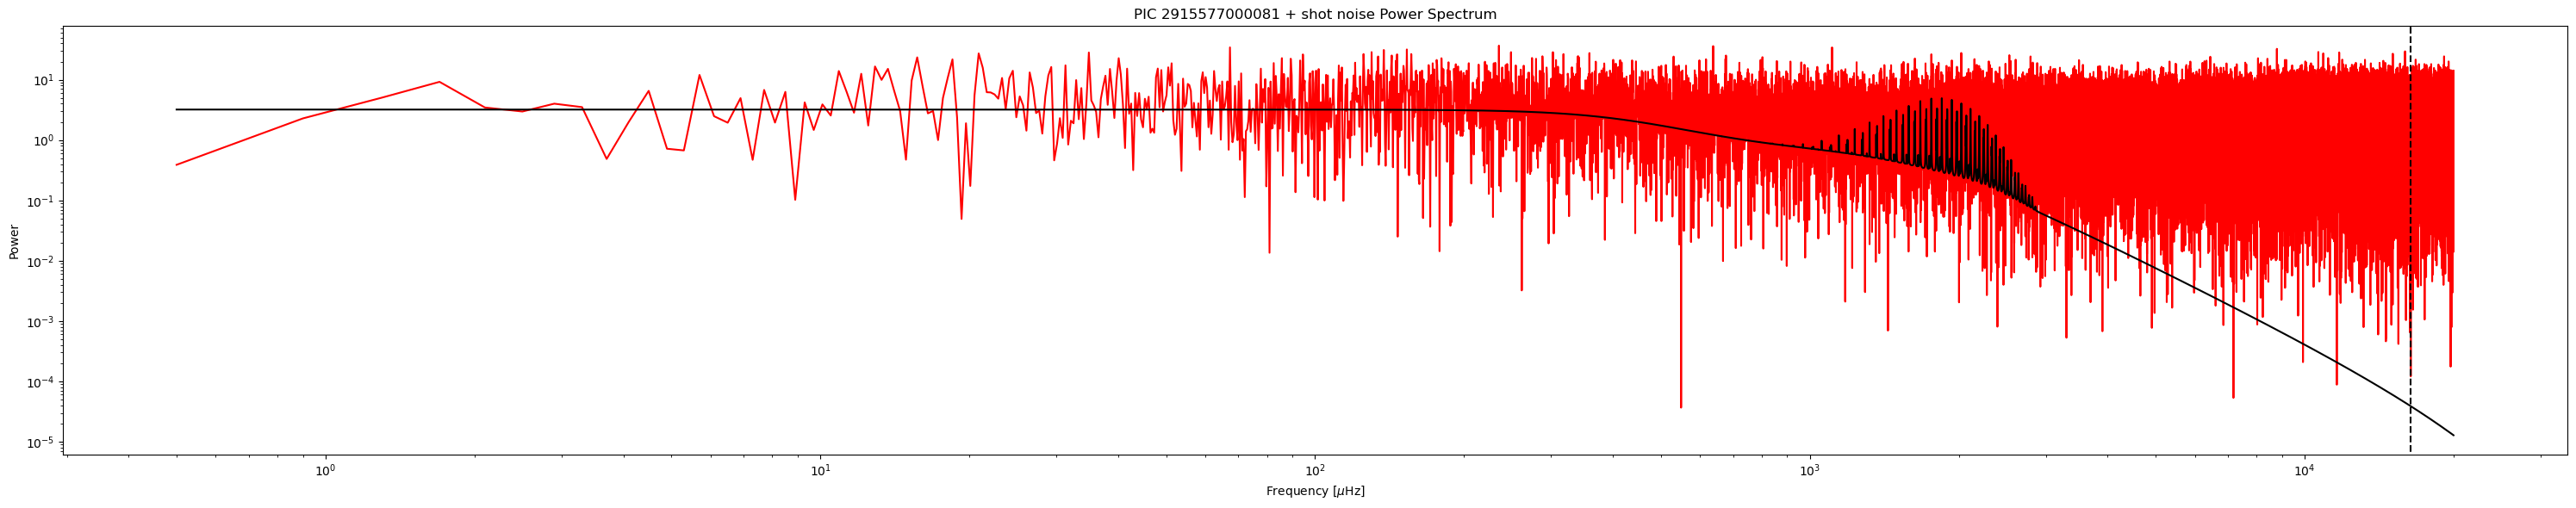

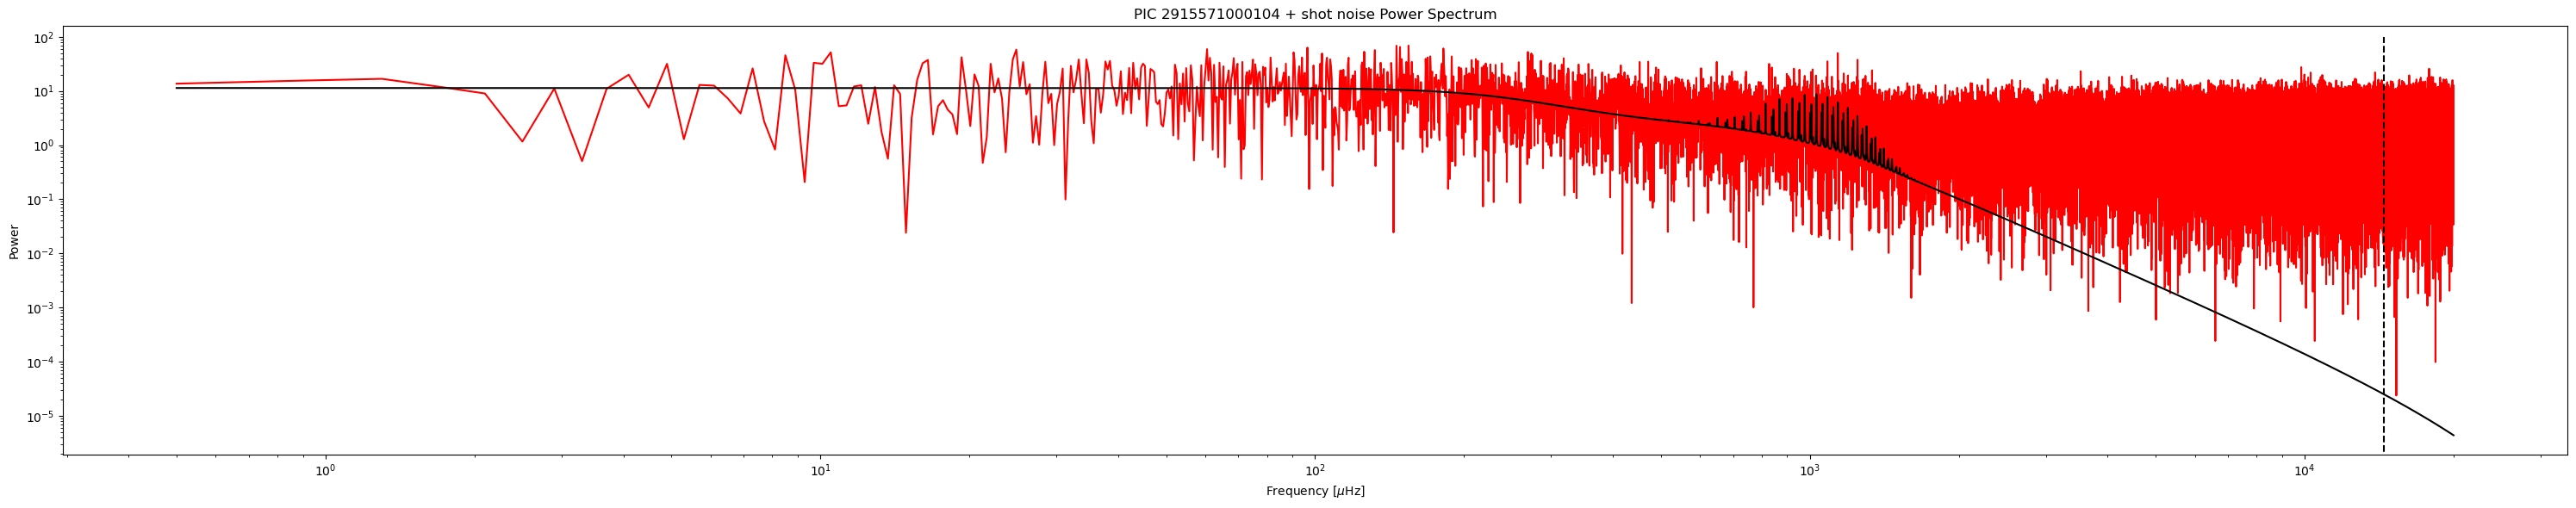

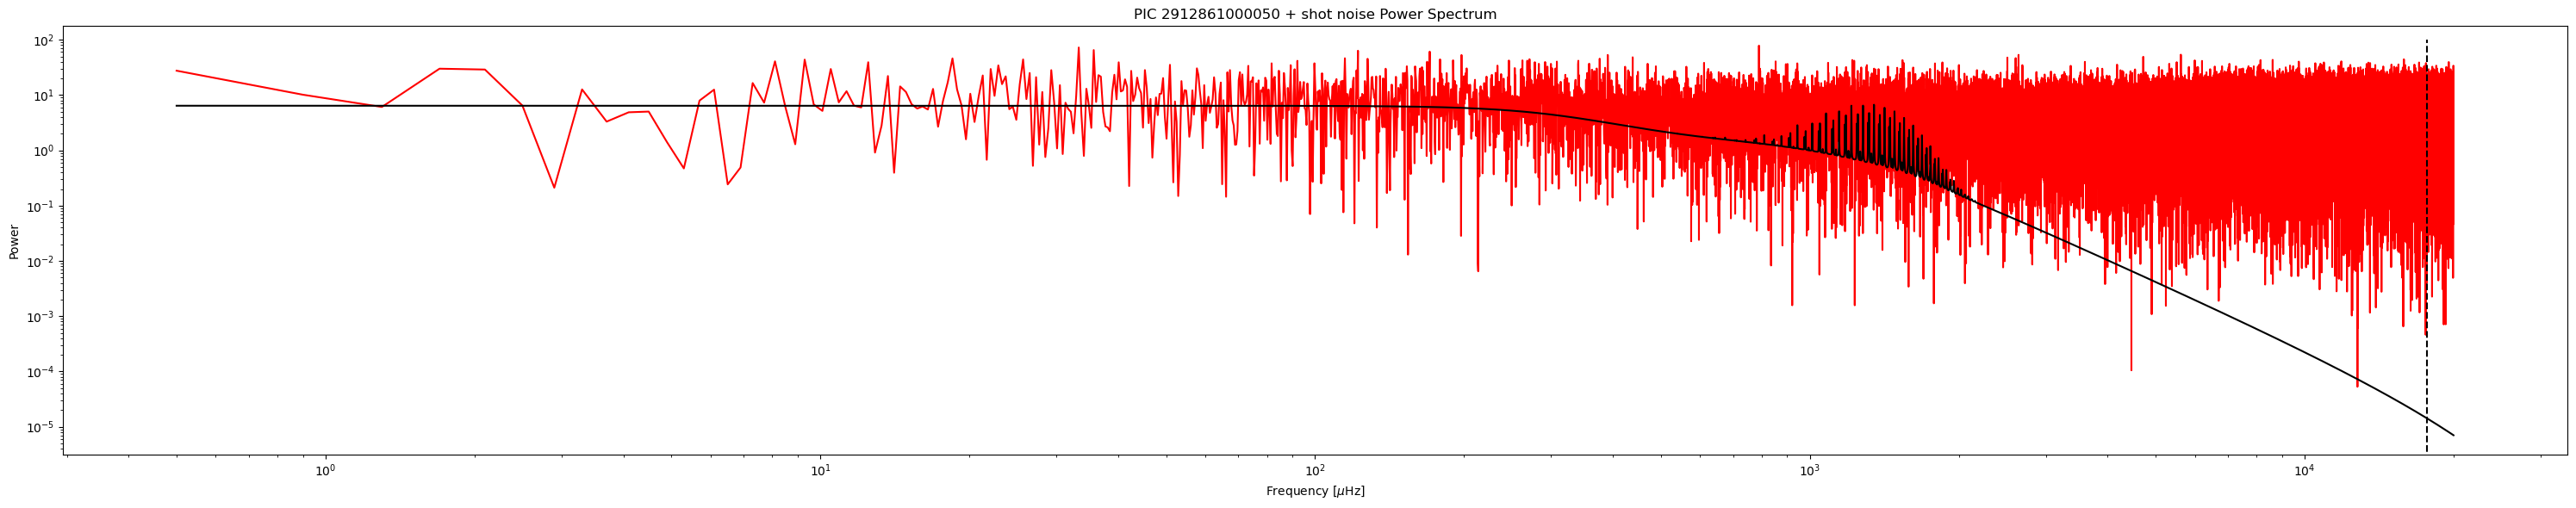

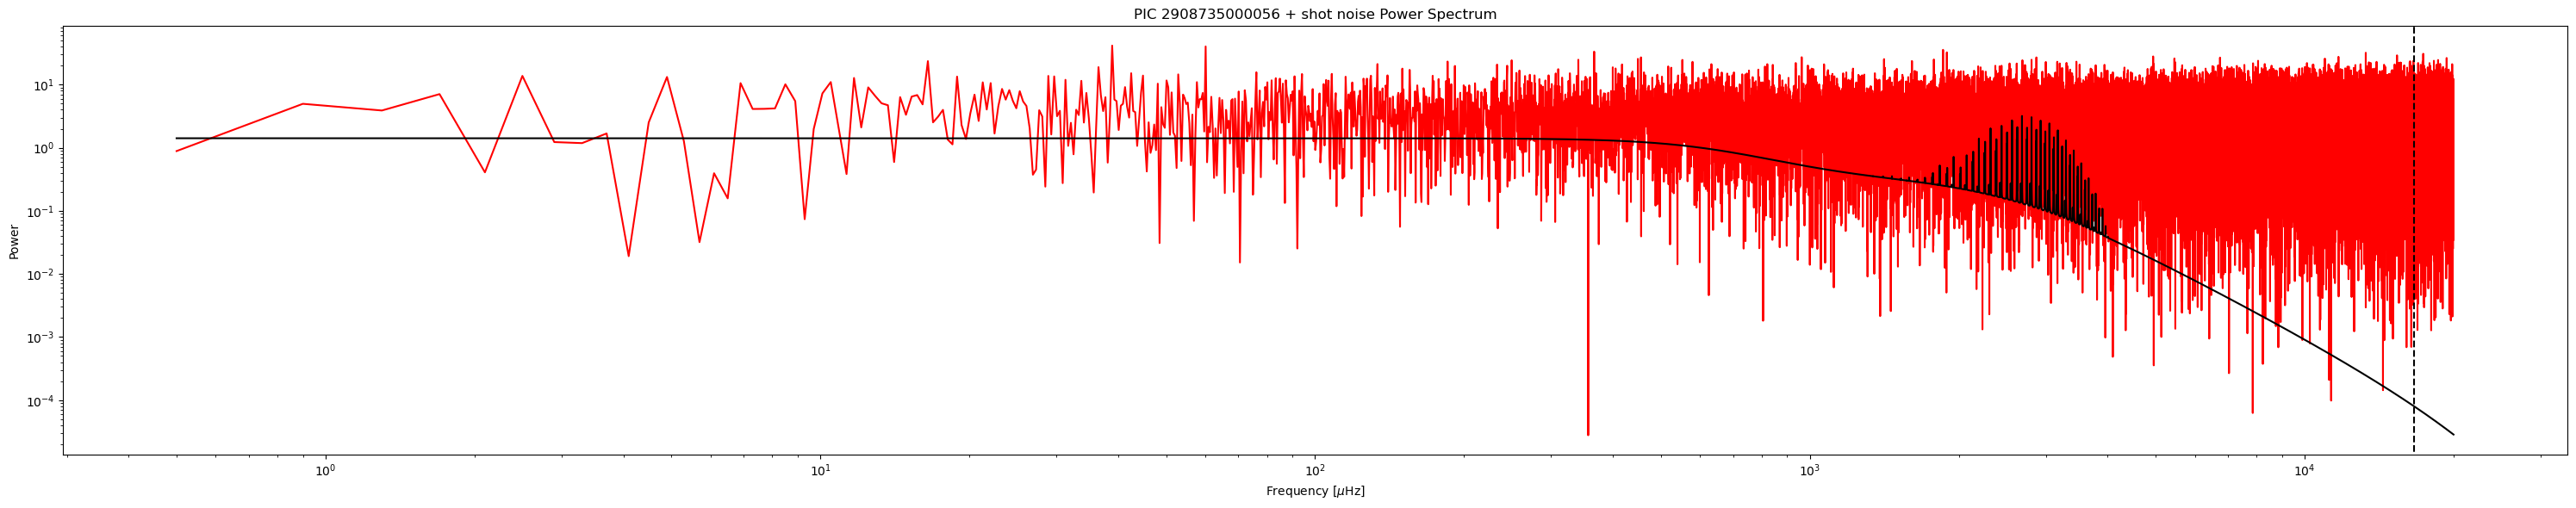

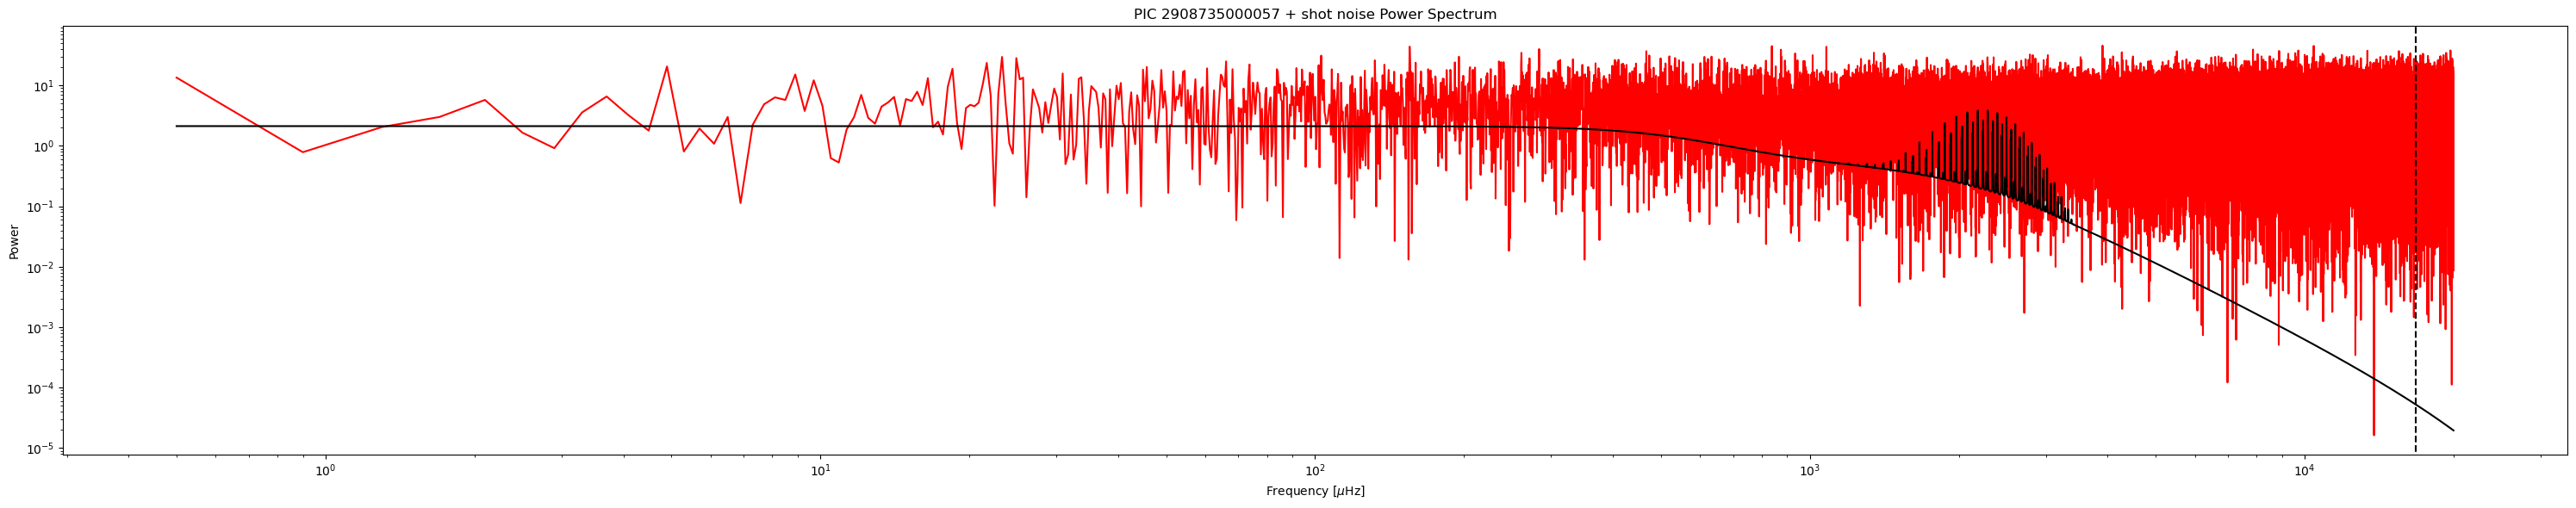

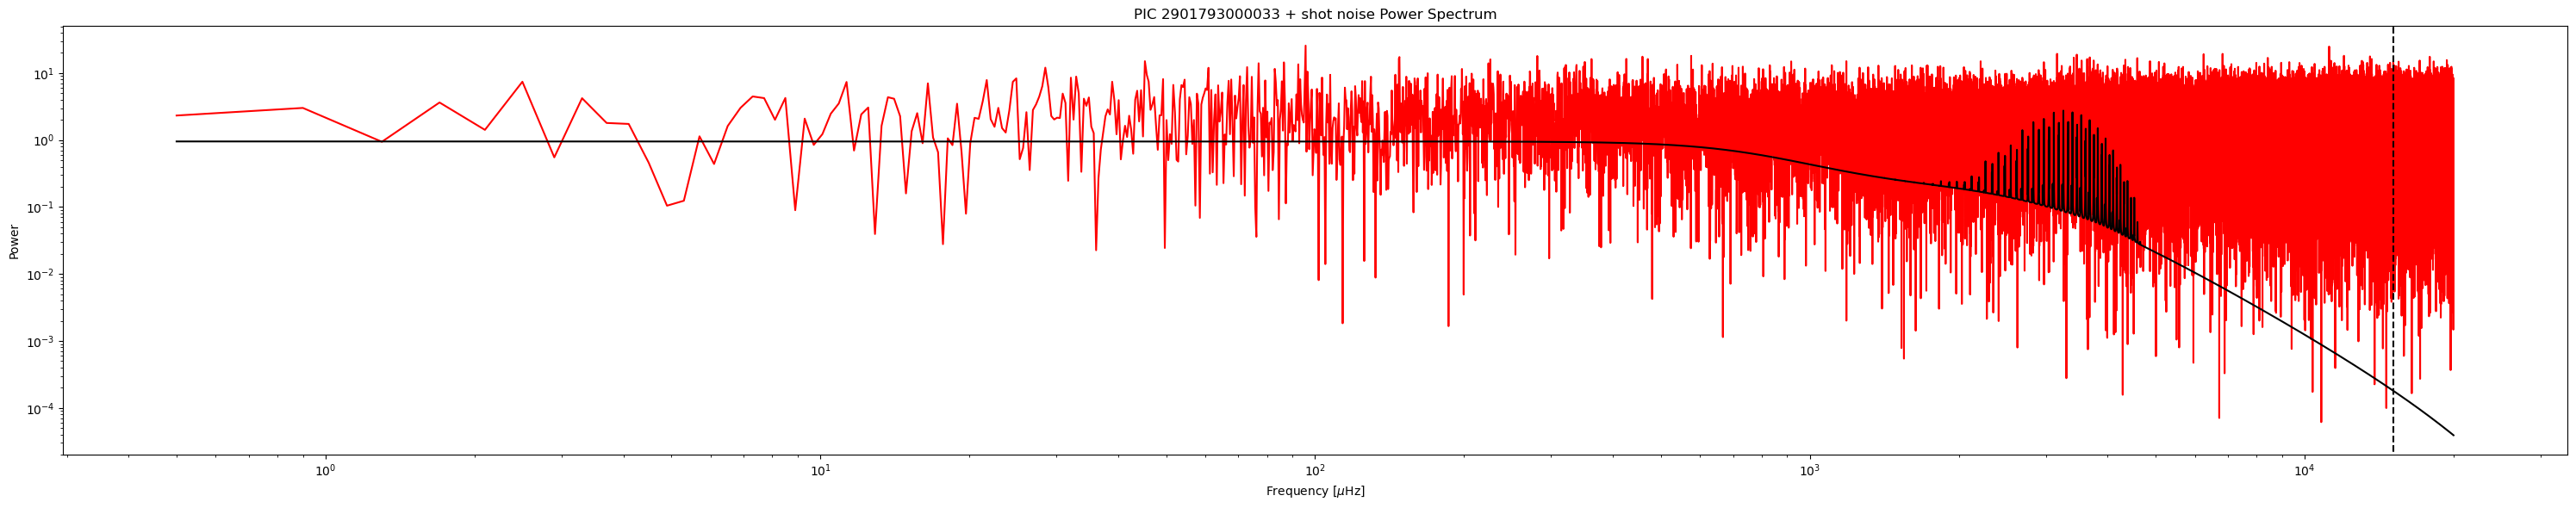

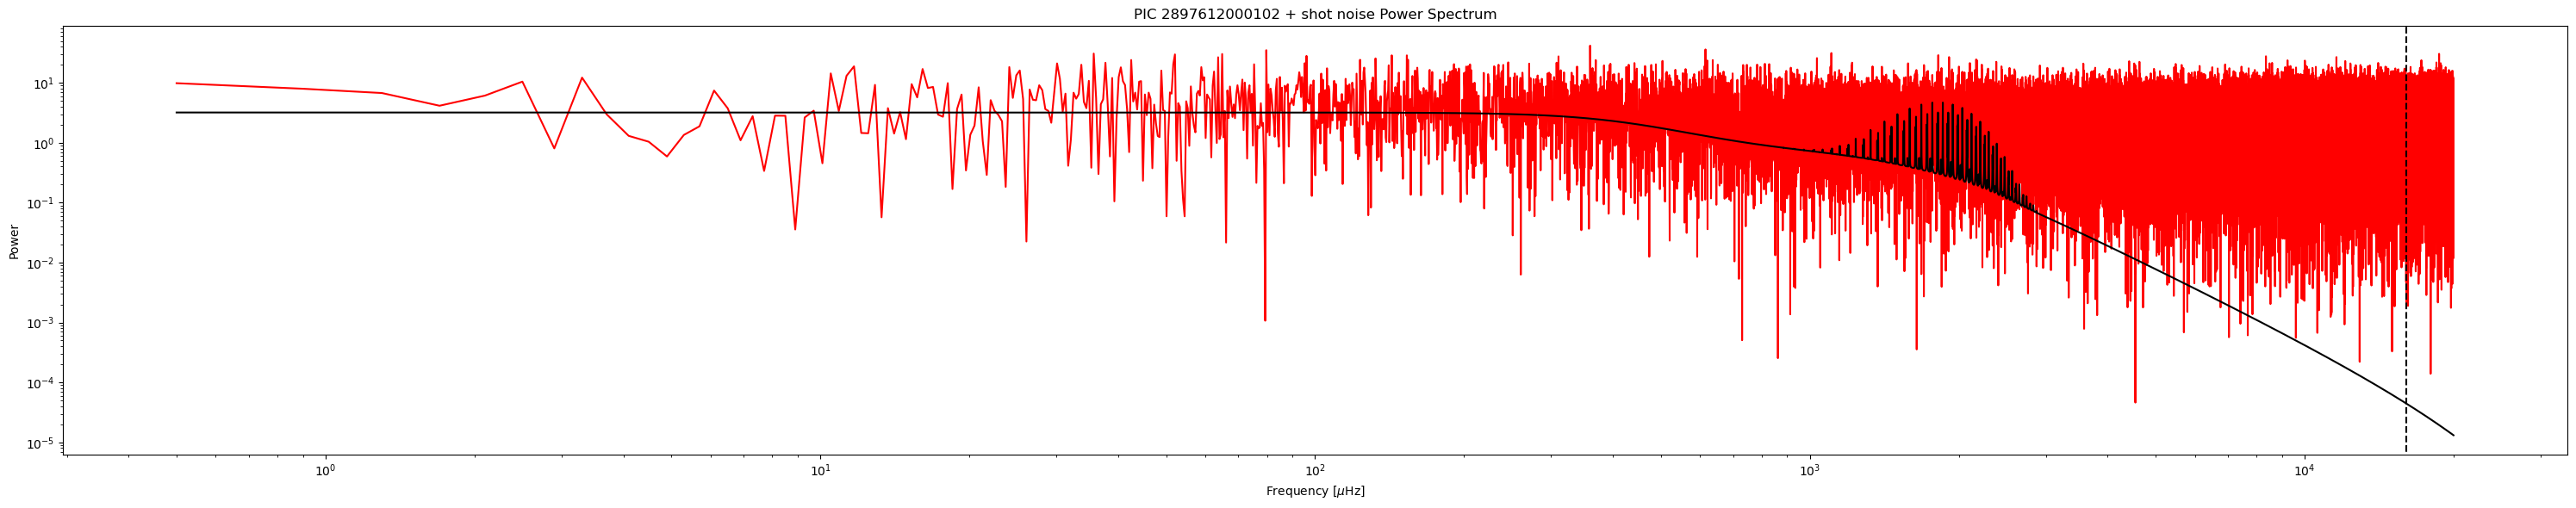

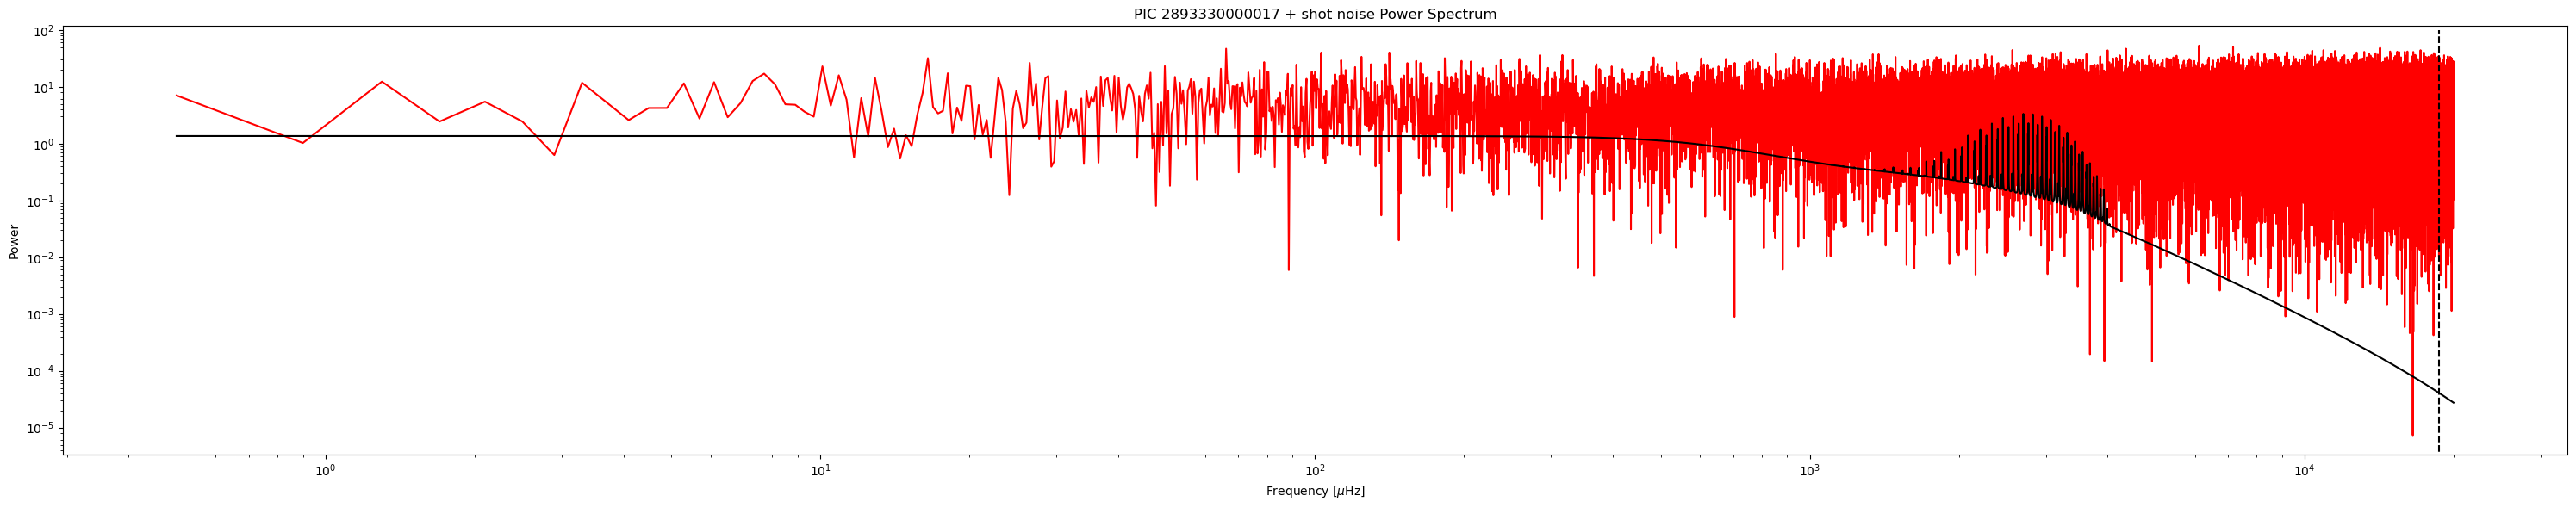

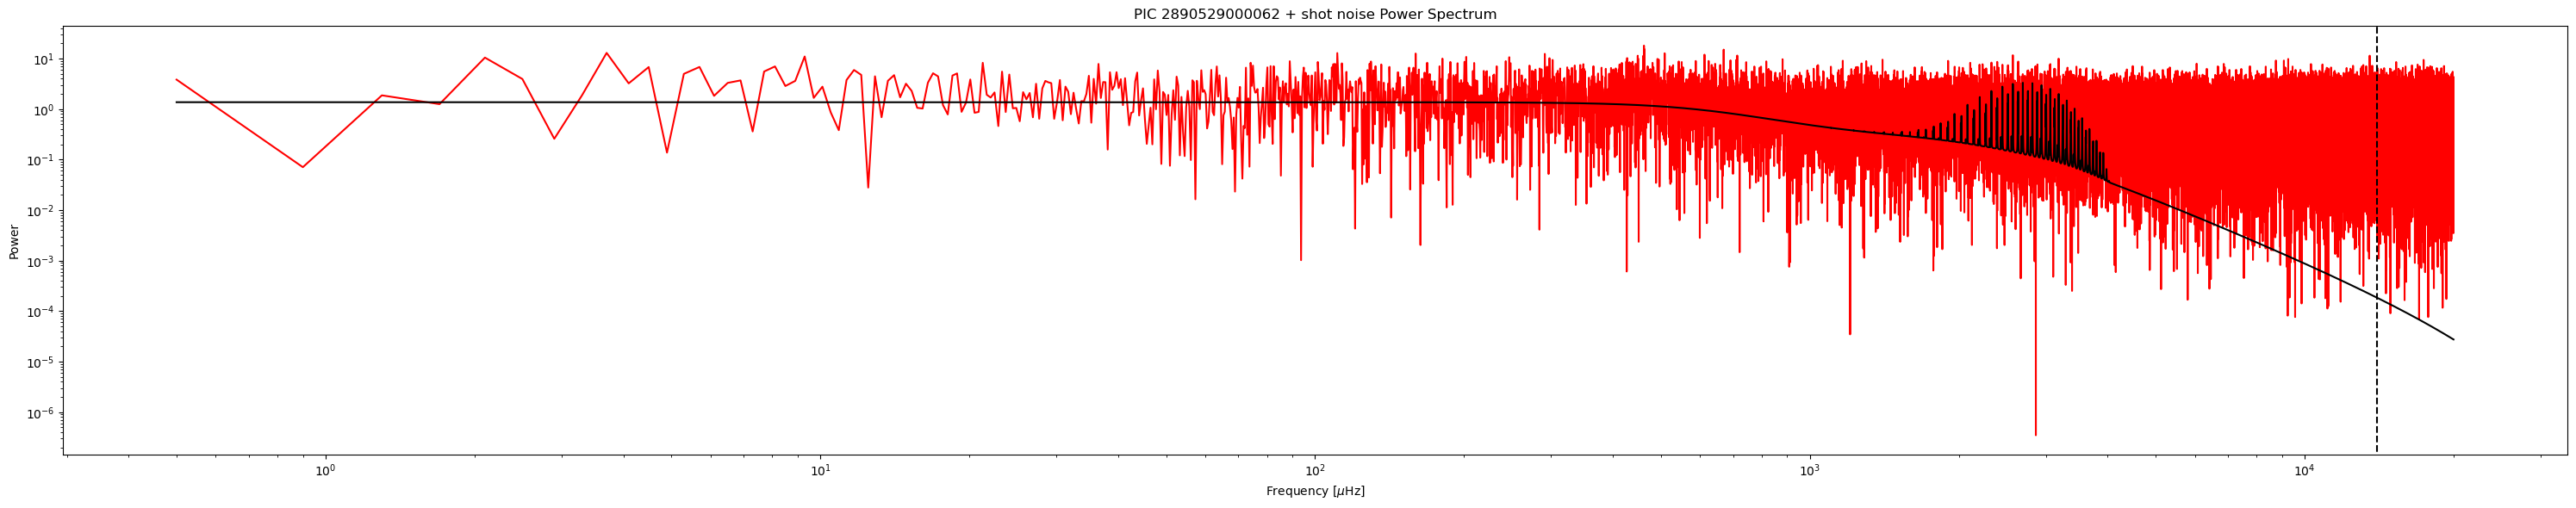

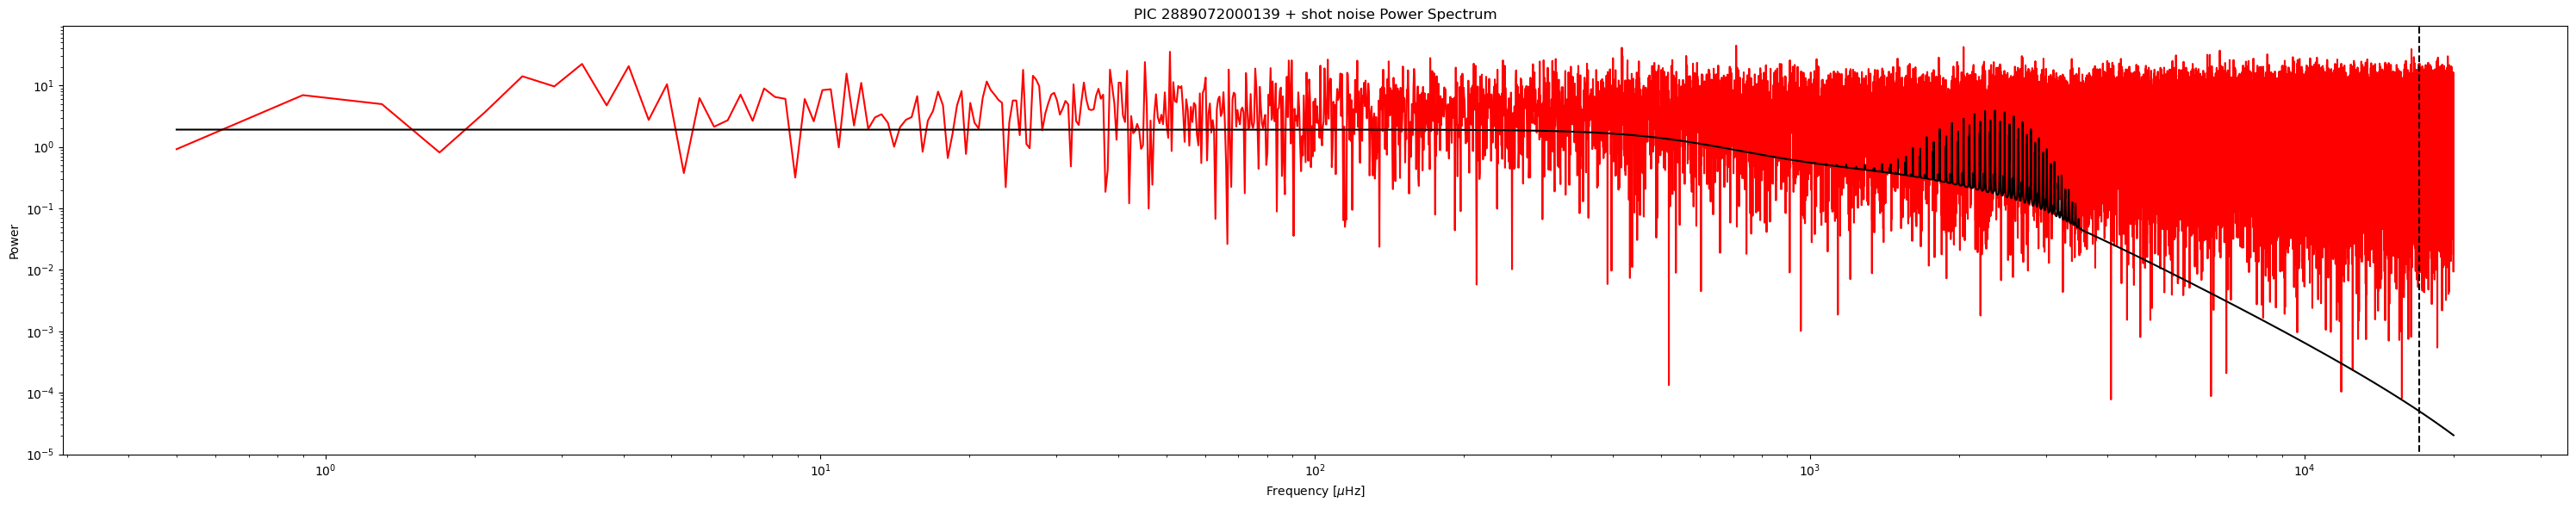

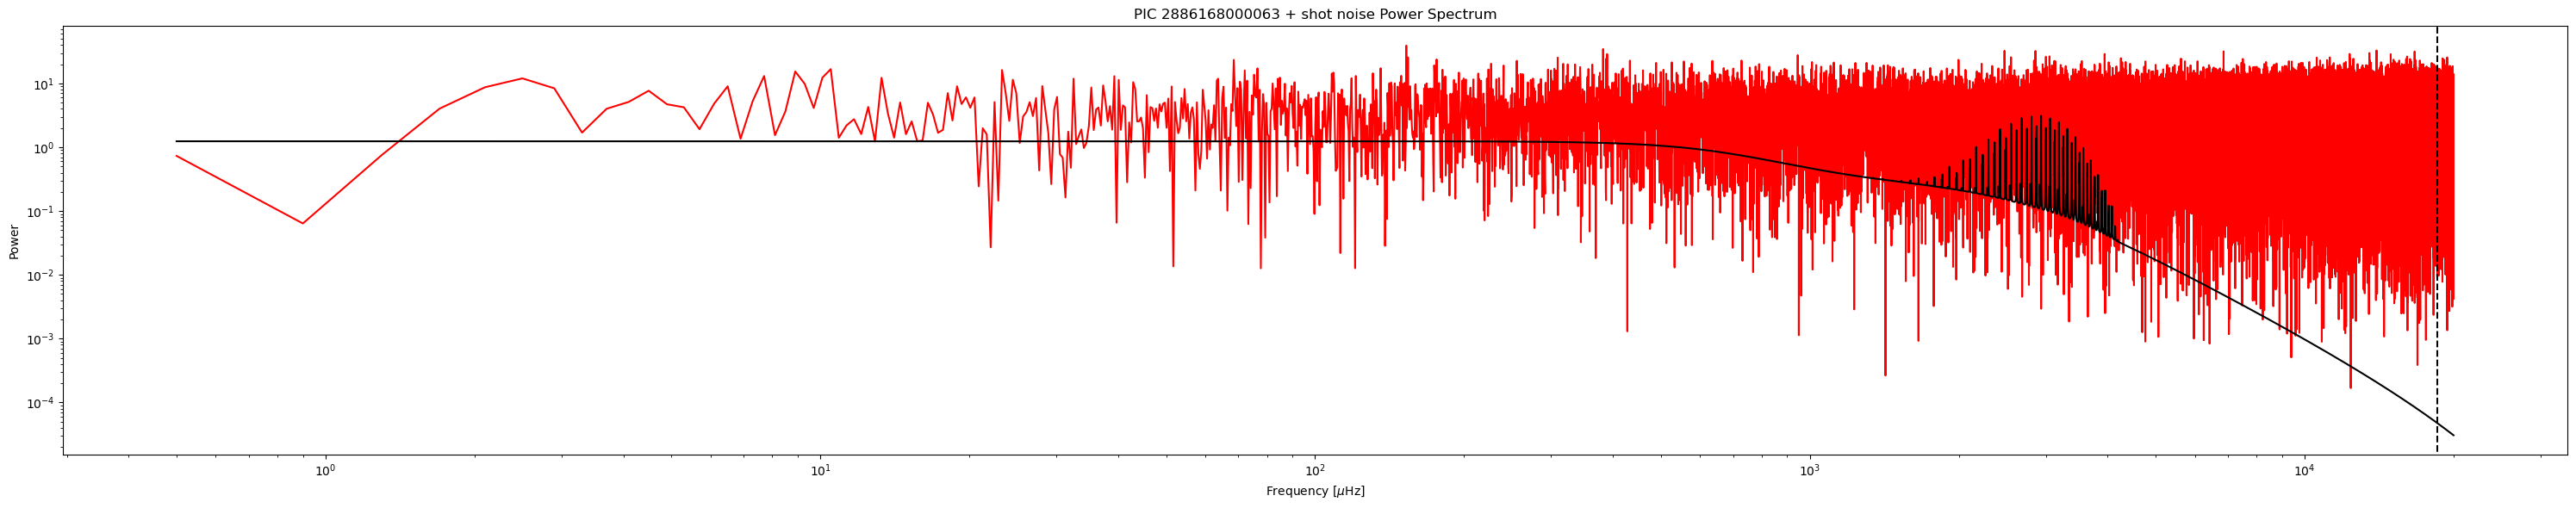

In [ ]:
# Prepare lists to store results
data_folder = r"C:\Users\douga\Documents\Asteroseismology\Simdata\star_list"
csv_files = glob.glob(os.path.join(data_folder, "*.csv"))
csv_files = csv_files[::-1]
labels = matched_picnames

freqs_list = []
powers_list = []
oscillations_noisy = []

nu_max_metrics_kepler = []
delta_nu_metrics_kepler = []
combined_metrics_kepler = []

delta_nu_fits = []
delta_nu_errs = []
nu_max_fits = []
nu_max_errs = []

noise_lvls = []
# Loop over all files

import pandas as pd

for f, label in zip(csv_files, labels):
    # Load frequency and power
    df = pd.read_csv(f, sep = ",", header = "infer")

    freq = df["Freq"].to_numpy()
    power = df["Power"].to_numpy()

    freqs_list.append(freq)
    powers_list.append(power)

    power_noisy = shot_noise(label, power)
    oscillations_noisy.append(power_noisy)

    nu_nyq = np.max(freq)
    delta_t = (10**6)/(2*nu_nyq)
    
    nu_max, delta_nu, lags_fit, acf_fit, delta_nu_est, acf_power = find_metric(power_noisy, freq)
    
    nu_max_metrics_kepler.append(nu_max)
    delta_nu_metrics_kepler.append(delta_nu)
    combined_metrics_kepler.append(nu_max * delta_nu)

    delta_nu_fit, delta_nu_err, nu_max_fit, nu_max_err = final_fit(lags_fit, acf_fit, delta_nu_est, acf_power)
    
    delta_nu_fits.append(delta_nu_fit)
    delta_nu_errs.append(delta_nu_err)
    nu_max_fits.append(nu_max_fit)
    nu_max_errs.append(nu_max_err)

    noise_lvl = find_noise_lvl(power_noisy, freq, nu_max_fit, nu_max_err)
    noise_lvls.append(noise_lvl) 
    
    plt.figure(figsize=(30,6))
    plt.plot(freq, power_noisy, c = "r")
    plt.plot(freq, power, c= "k")
    plt.xlabel("Frequency [$\mu$Hz]")
    plt.ylabel("Power")
    plt.title(f"{label} + shot noise Power Spectrum")
    plt.yscale("log")
    plt.xscale("log")
    plt.vlines(nu_max_fit, 0, 100, linestyles = "dashed", color = "k")
    plt.tight_layout()
    plt.show()     

# Convert to NumPy arrays for convenience
freqs_list = np.array(freqs_list)
powers_list = np.array(powers_list)
nu_max_metrics_kepler = np.array(nu_max_metrics_kepler, dtype=float)
delta_nu_metrics_kepler = np.array(delta_nu_metrics_kepler, dtype=float)
combined_metrics_kepler = np.array(combined_metrics_kepler, dtype=float)
delta_nu_fits = np.array(delta_nu_fits)
delta_nu_errs = np.array(delta_nu_errs)
nu_max_fits = np.array(nu_max_fits)
nu_max_errs = np.array(nu_max_errs)
noise_lvls = np.array(noise_lvls)

print("Nu_max metrics:", nu_max_metrics_kepler)
print("Delta_nu metrics:", delta_nu_metrics_kepler)
print("Combined metrics:", combined_metrics_kepler)
print("Delta_nu:", delta_nu_fits)
print("Delta_nu errors:", delta_nu_errs)
print("Nu_max:", nu_max_fits)
print("Nu_max errors:", nu_max_errs)
print("Noise levels:", noise_lvls)

In [16]:
i= 0

nu_nyq = np.max(freq)
delta_t = 10**(6)/(2*np.max(freq))
print(f"Nyquist frequency: {nu_nyq:.2f}")
print(delta_t)

T = 30*24*60*60 #30 days
N = int(T/(2*delta_t))
#N=len(freq)
print(f"Number of data points: {N}")

freq_noise=np.linspace(0,nu_nyq,N)
powers_noise=fake_signals(freq_noise,500,noise_lvls[i])

nu_max_metrics_noise = []
delta_nu_metrics_noise = []
combined_metrics_noise = []
for power in tqdm(powers_noise):
    nu_max, delta_nu, lags_fit, acf_fit, delta_nu_est, acf_power = find_metric(power, freq_noise)

    nu_max_metrics_noise.append(nu_max)
    delta_nu_metrics_noise.append(delta_nu)
    combined_metrics_noise.append(nu_max * delta_nu)

nu_max_metrics_noise = np.array(nu_max_metrics_noise)
delta_nu_metrics_noise = np.array(delta_nu_metrics_noise)
combined_metrics_noise = np.array(combined_metrics_noise)

Nyquist frequency: 20000.00
25.0
Number of data points: 49999


  4%|▍         | 22/500 [00:05<01:55,  4.13it/s]


KeyboardInterrupt: 

In [8]:
plt.figure(figsize=(6,4))
plt.hist(nu_max_metrics_noise, bins=75, density=True, alpha = 0.6)

for p in [95, 99, 99.9]:
    thr = np.percentile(nu_max_metrics_noise, p)
    plt.axvline(thr, linestyle="--", label=f"{p}% = {thr:.3f}", color = "r")
#for nu_max in nu_max_metrics_kepler:
plt.axvline(nu_max_metrics_kepler[i], linestyle = "--", label = f"{labels[i]} = {nu_max_metrics_kepler[i]:.2f}", color = "k")
plt.xlabel("νmax detection metric (ACF strength)")
plt.ylabel("Probability density")
plt.title("Noise-only νmax metric distribution")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'nu_max_metrics_noise' is not defined

<Figure size 600x400 with 0 Axes>

In [7]:
def threshold_from_x(x, sig_cad, freq, p):
    nu_nyq = np.max(freq)
    delta_t = 10**(6)/(2*nu_nyq)
    T = 30*24*60*60 #30 days
    N=int(len(freq))
    
    #turn x back into noise_lvl

    sig1hr = (1+x)*sig_cad / np.sqrt(3600/delta_t)
    noise_lvl = (sig1hr**2) * 2 * 3600 * 10**(-6)
    
    freq_noise=np.linspace(0,nu_nyq,N)
    powers_noise=fake_signals(freq_noise,100,noise_lvl)

    nu_max_metrics_noise = []
    #delta_nu_metrics_noise = []
    #combined_metrics_noise = []
    
    for power in tqdm(powers_noise):
        nu_max, delta_nu, lags_fit, acf_fit, delta_nu_est, acf_power = find_metric(power, freq_noise)
    
        nu_max_metrics_noise.append(nu_max)
        #delta_nu_metrics_noise.append(delta_nu)
        #combined_metrics_noise.append(nu_max * delta_nu)
    
    nu_max_metrics_noise = np.array(nu_max_metrics_noise)
    #delta_nu_metrics_noise = np.array(delta_nu_metrics_noise)
    #combined_metrics_noise = np.array(combined_metrics_noise)

    threshold = np.percentile(nu_max_metrics_noise, p)

    return threshold

def make_spectrum_noisy(x, sig_cad, time, flux, label):
    noise = np.random.normal(0,x*sig_cad, size = len(time))
    flux_noisy = flux + noise
    
    P = psd(label, time=time, flux=flux_noisy)
    P()  # Compute power spectrum
    freq_noisy = P.freq  # frequency in μHz
    power_noisy = P.powerdensity  # power density in ppm^2/μHz

    return flux_noisy, freq_noisy, power_noisy

def make_multiple_noisy_spectra(N, x, sig_cad, time, flux, label):
    
    fluxes_noisy = []
    freqs_noisy = []
    powers_noisy = []

    for _ in tqdm(range(N)):
        flux_n, freq_n, power_n = make_spectrum_noisy(x, sig_cad, time, flux, label)
        fluxes_noisy.append(flux_n)
        freqs_noisy.append(freq_n)
        powers_noisy.append(power_n)

    return fluxes_noisy, freqs_noisy, powers_noisy

def detection_probability(x, sig_cad, freq, p, n, time, flux, label):
    threshold = thresholds1[x]
    fluxes_noisy, freqs_noisy, powers_noisy = make_multiple_noisy_spectra(n, x, sig_cad, time, flux, label)

    nu_max_metrics_x = []
    delta_nu_metrics_x = []

    for power, freq_i in tqdm(zip(powers_noisy, freqs_noisy)):
        nu_max_metric, delta_nu_metric, *_  = find_metric(power,freq_i)
        nu_max_metrics_x.append(nu_max_metric)
        delta_nu_metrics_x.append(delta_nu_metric)

    nu_max_metrics_x = np.array(nu_max_metrics_x)

    mean_nu_max_metric = np.mean(nu_max_metrics_x)
    detection_prob = np.sum(nu_max_metrics_x > threshold) / len(nu_max_metrics_x)
        
    return mean_nu_max_metric, detection_prob

In [ ]:
noise_lvls = np.array(noise_lvls)
sig1hrs = (noise_lvls / (2*3600*10**(-6)))**(1/2)
sig_cads = sig1hrs * np.sqrt(3600/delta_t)
print(sig_cads[0])
np.save("sig_cads.npy", sig_cads)

In [ ]:
x_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1, 1.2]

In [ ]:
sim_thresholds1 = {
    x: threshold_from_x(x, sig_cads[0], freq, 99)
    for x in x_values
}

np.save("sim_thresholds1.npy", sim_thresholds1)

In [ ]:
threshold_vals3 = np.array([thresholds3[xi] for xi in x_values])

In [ ]:
#thresholds1 = np.load("thresholds1.npy", allow_pickle = True).item()


In [ ]:
mean_nu_max_metrics3 = []
detection_probs3 = []
for x in x_values:
    mean_nu_max_metric, detection_prob = detection_probability(x, sig_cads[i], freqs_list[i], 99, 100, times_list[i], fluxes_list[i], labels[i])
    mean_nu_max_metrics3.append(mean_nu_max_metric)
    detection_probs3.append(detection_prob)

np.save("mean_nu_max_metrics3.npy", mean_nu_max_metrics3)
np.save("detection_probs3.npy", detection_probs3)

In [ ]:
mean_nu_max_metrics3 = np.array(mean_nu_max_metrics3)
detection_probs3 = np.array(detection_probs3)

In [ ]:
print(mean_nu_max_metrics3)
print(detection_probs2)

In [ ]:
detection_probs = np.load("detection_probs.npy", allow_pickle = True)
detection_probs2 = np.load("detection_probs2.npy", allow_pickle = True)
detection_probs3 = np.load("detection_probs3.npy", allow_pickle = True)
sig1hrs = np.load("sig1hrs.npy", allow_pickle = True)
thresholds1 = np.load("thresholds1.npy", allow_pickle = True).item()
thresholds2 = np.load("thresholds2.npy", allow_pickle = True).item()
thresholds3 = np.load("thresholds3.npy", allow_pickle = True).item()
mean_nu_max_metrics = np.load("mean_nu_max_metrics.npy", allow_pickle = True)
mean_nu_max_metrics2 = np.load("mean_nu_max_metrics2.npy", allow_pickle = True)
mean_nu_max_metrics3 = np.load("mean_nu_max_metrics3.npy", allow_pickle = True)
sig_cads = np.load("sig_cads.npy", allow_pickle = True)

In [ ]:
x_50_1 = np.interp(0.5, detection_probs[::-1], x_values[::-1])
print(x_50_1)
x_50_2 = np.interp(0.5, detection_probs2[::-1], x_values[::-1])
print(x_50_2)
x_50_3 = np.interp(0.5, detection_probs3[::-1], x_values[::-1])
print(x_50_3)

x_50s = [x_50_1, x_50_2, x_50_3]
x_50s = np.array(x_50s)
print(x_50s)

threshold_vals1 = np.array([thresholds1[xi] for xi in x_values])
threshold_vals2 = np.array([thresholds2[xi] for xi in x_values])
threshold_vals3 = np.array([thresholds3[xi] for xi in x_values])

In [ ]:
def sigmoid(x, k, x0):
    return 1 / (1 + np.exp(-k * (x - x0)))

def sigmoid_fit(x, detection_probs, x_50):
    p0 = [x_50_1, 0.8]
    params, cov = curve_fit(sigmoid, x, detection_probs, p0=p0)
    k_fit, x_50_fit = params
    return k_fit, x_50_fit

k_fit1, x_50_fit1 = sigmoid_fit(x_values, detection_probs, x_50_1)
print(k_fit1, x_50_fit1)

#k_fit2, x_50_fit2 = sigmoid_fit(x_values, detection_probs2, x_50_2)
#print(k_fit2, x_50_fit2)
#it cant fit a sigmoid to the second one for some reason

k_fit3, x_50_fit3 = sigmoid_fit(x_values, detection_probs3, x_50_3)
print(k_fit3, x_50_fit3)

In [ ]:
x_smooth = np.linspace(0,1.2,300)

plt.plot(x_values, detection_probs)
plt.plot(x_smooth, sigmoid(x_smooth, k_fit1, x_50_fit1))
plt.title(f"Detection probability at different multiples of noise x for {labels[0]}")
plt.ylabel("Detection probability")
plt.xlabel("x")
plt.hlines(0.5, 0, 1.2, linestyles = "dashed", colors = "red")
plt.vlines(x_50_1, 0, 1, linestyles = "dashed", colors = "red", label = "50% detection probability")
plt.legend()
plt.show()

plt.plot(x_values, detection_probs2)
plt.title(f"Detection probability at different multiples of noise x for {labels[1]}")
plt.ylabel("Detection probability")
plt.xlabel("x")
plt.hlines(0.5, 0, 1.2, linestyles = "dashed", colors = "red")
plt.vlines(x_50_2, 0, 1, linestyles = "dashed", colors = "red", label = "50% detection probability")
plt.legend()
plt.show()

plt.plot(x_values, detection_probs3)
plt.plot(x_smooth, sigmoid(x_smooth, k_fit3, x_50_fit3))
plt.title(f"Detection probability at different multiples of noise x for {labels[2]}")
plt.ylabel("Detection probability")
plt.xlabel("x")
plt.hlines(0.5, 0, 1.2, linestyles = "dashed", colors = "red")
plt.vlines(x_50_3, 0, 1, linestyles = "dashed", colors = "red", label = "50% detection probability")
plt.legend()
plt.show()


In [ ]:
plt.plot(x_values, mean_nu_max_metrics, label = "Mean nu max SNR")
plt.plot(x_values, threshold_vals1, label = "Threshold SNR")
plt.title(f"Mean nu max SNR and thresholds SNR against x for {labels[0]}")
plt.vlines(x_50_1, 2.5, 4.5, linestyles = "dashed", colors = "red", label = "50% detection probability")
plt.xlabel("x")
plt.ylabel("SNR")
plt.legend()
plt.show()

plt.plot(x_values, mean_nu_max_metrics2, label = "Mean nu max SNR")
plt.plot(x_values, threshold_vals2, label = "Threshold SNR")
plt.title(f"Mean nu max SNR and thresholds SNR against x for {labels[1]}")
plt.vlines(x_50_2, 2.5, 4.0, linestyles = "dashed", colors = "red", label = "50% detection probability")
plt.xlabel("x")
plt.ylabel("SNR")
plt.legend()
plt.show()

plt.plot(x_values, mean_nu_max_metrics3, label = "Mean nu max SNR")
plt.plot(x_values, threshold_vals3, label = "Threshold SNR")
plt.title(f"Mean nu max SNR and thresholds SNR against x for {labels[2]}")
plt.vlines(x_50_3, 2.5, 4.5, linestyles = "dashed", colors = "red", label = "50% detection probability")
plt.xlabel("x")
plt.ylabel("SNR")
plt.legend()
plt.show()

In [ ]:
nu_nyqs = [np.max(freqs_list[0]), np.max(freqs_list[1]), np.max(freqs_list[2])]
nu_nyqs = np.array(nu_nyqs)
delta_ts = 10**(6)/(2*nu_nyqs)
sig1hrs_thresh = (1+x_50s)*sig_cads / np.sqrt(3600/delta_ts)
print(sig1hrs_thresh)
np.save("sig1hrs_thresh.npy", sig1hrs_thresh)

In [ ]:
for nu_max_fit, sig1hr, label in zip(nu_max_fits, sig1hrs_thresh, labels):
    plt.scatter(np.sort(nu_max_fit), np.sort(sig1hr), label = label)
plt.title("Threshold sig1hr noise against nu max")
plt.xlabel("Nu max")
plt.ylabel("Sig1hr")
plt.legend()